# House Prices Prediction

Exploratory analysis and house price prediction project using Python.

The goal is to build a machine learning model capable of predicting the sale price of a house based on its features.
Throughout the code, comments have been added to guide the reader through the author's train of thought.

## Technologies used

- Python
- pandas
- NumPy
- matplotlib
- scikit-learn

## Project timeline

1. Data loading and initial exploration.
2. Data cleaning and preparation.
3. Exploratory data analysis.
4. Modeling.
5. Feature importance analysis.
6. Conclusions.

In [54]:

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor

## 1. Data loading and initial exploration

In this section the dataset is loaded and a first exploration is carried out to understand its structure and available values.

In [55]:
df = pd.read_csv("../data/train.csv")

print(df.head())
df.info()
print(df.isnull().sum().sort_values(ascending=False))

   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0    NaN   NaN         NaN       0     12   

  YrSold  SaleType  SaleCondition  SalePrice  
0   2008        WD   

## 2. Data cleaning and preparation

Null values are handled taking into account the meaning of each variable. Some columns with many null values represent the absence of a feature, such as a pool, fireplace, garage or basement.

In [56]:
#The absence of PoolQC probably indicates that the house has no pool. Therefore we will replace it with a Pool column that will be a binary variable

df["Pool"] = df["PoolQC"].notnull().astype(int)
df = df.drop("PoolQC", axis=1)

#Since these variables are not very important for the price of a house and most of their values are empty, we will remove them.
df = df.drop(["Fence", "Alley"], axis=1)
df = df.drop("MiscFeature", axis=1)

df["MasVnrType"] = df["MasVnrType"].fillna("None")

print(df.isnull().sum().sort_values(ascending=False).head(20))

#For Fireplace we proceed the same way as with Pool:
df["Fireplace"] = df["FireplaceQu"].notnull().astype(int)
df = df.drop("FireplaceQu", axis=1)

#The absence of this variable no longer indicates that the house lacks this feature, since many houses have some kind of frontage.
#Therefore, we will fill it with the median, which is less affected by atypically high values:
df["LotFrontage"] = df["LotFrontage"].fillna(df["LotFrontage"].median())

#The missing data in the garage features, since they all match in number, most likely means that these houses have no
#garage. We will fill them with None:
df["GarageType"] = df["GarageType"].fillna("None")
df["GarageQual"] = df["GarageQual"].fillna("None")
df["GarageFinish"] = df["GarageFinish"].fillna("None")
df["GarageCond"] = df["GarageCond"].fillna("None")
df["GarageYrBlt"] = df["GarageYrBlt"].fillna(0)

#Same with Bsmt:
df["BsmtFinType2"] = df["BsmtFinType2"].fillna("None")
df["BsmtFinType1"] = df["BsmtFinType1"].fillna("None")
df["BsmtExposure"] = df["BsmtExposure"].fillna("None")
df["BsmtQual"] = df["BsmtQual"].fillna("None")
df["BsmtCond"] = df["BsmtCond"].fillna("None")

#The absence of MasVnrArea is probably because the house has no special facade, so we fill it with 0.
#As for Electrical, it is rather odd for a house to have no electricity, so we simply use the mode of this variable.
df["MasVnrArea"] = df["MasVnrArea"].fillna(0)
df["Electrical"] = df["Electrical"].fillna(df["Electrical"].mode()[0])

print(df.isnull().sum().sort_values(ascending=False).head(20))

FireplaceQu     690
LotFrontage     259
GarageType       81
GarageQual       81
GarageFinish     81
GarageYrBlt      81
GarageCond       81
BsmtFinType2     38
BsmtExposure     38
BsmtCond         37
BsmtFinType1     37
BsmtQual         37
MasVnrArea        8
Electrical        1
Condition2        0
Condition1        0
Neighborhood      0
LandSlope         0
LotConfig         0
Utilities         0
dtype: int64
Id              0
MSSubClass      0
MSZoning        0
LotFrontage     0
LotArea         0
Street          0
LotShape        0
LandContour     0
Utilities       0
LotConfig       0
LandSlope       0
Neighborhood    0
Condition1      0
Condition2      0
BldgType        0
HouseStyle      0
OverallQual     0
OverallCond     0
YearBuilt       0
YearRemodAdd    0
dtype: int64


## 3. Exploratory data analysis

In this section the target variable `SalePrice` and its relationship with some of the most relevant variables in the dataset are analyzed.

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


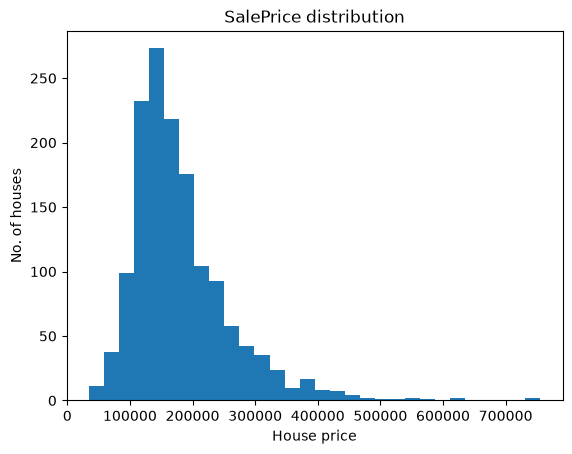

In [57]:
print(df["SalePrice"].describe()) #we get a general overview of the target variable.

#Let's see what shape the distribution of the target variable has:
plt.figure('House price distribution')
plt.hist(df["SalePrice"], bins=30)
plt.title('SalePrice distribution')
plt.xlabel("House price")
plt.ylabel("No. of houses")
plt.show()

In the resulting plot, we can see that the distribution of SalePrice has a large concentration around mid values. It is also
worth noting that it has a longer tail on the right, with values further away from the main concentration of houses;
this means that the distribution has a positive (right) skew. In addition, there are several values very far
from the central ones. This shows us that the distribution has several outliers.

### Correlations with the target variable

The correlations between the numerical variables and `SalePrice` are computed to identify which features have a stronger linear relationship with the sale price. We also plot, in some charts, the variables most correlated with the target variable "against" it.

SalePrice        1.000000
OverallQual      0.790982
GrLivArea        0.708624
GarageCars       0.640409
GarageArea       0.623431
TotalBsmtSF      0.613581
1stFlrSF         0.605852
FullBath         0.560664
TotRmsAbvGrd     0.533723
YearBuilt        0.522897
YearRemodAdd     0.507101
MasVnrArea       0.472614
Fireplace        0.471908
Fireplaces       0.466929
BsmtFinSF1       0.386420
LotFrontage      0.334771
WoodDeckSF       0.324413
2ndFlrSF         0.319334
OpenPorchSF      0.315856
HalfBath         0.284108
LotArea          0.263843
GarageYrBlt      0.261366
BsmtFullBath     0.227122
BsmtUnfSF        0.214479
BedroomAbvGr     0.168213
ScreenPorch      0.111447
Pool             0.093708
PoolArea         0.092404
MoSold           0.046432
3SsnPorch        0.044584
BsmtFinSF2      -0.011378
BsmtHalfBath    -0.016844
MiscVal         -0.021190
Id              -0.021917
LowQualFinSF    -0.025606
YrSold          -0.028923
OverallCond     -0.077856
MSSubClass      -0.084284
EnclosedPorc

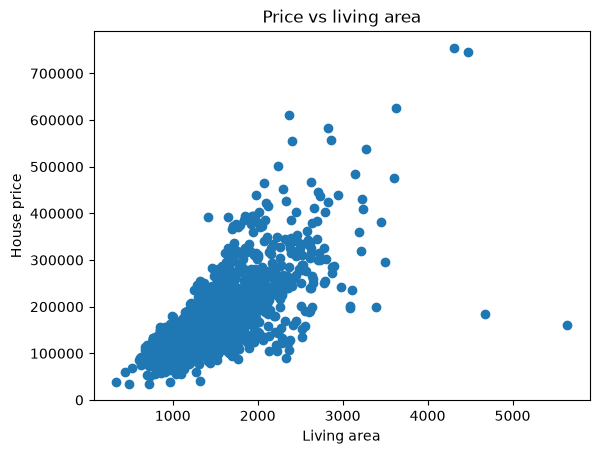

In [58]:
corr = df.corr(numeric_only=True)
print(corr["SalePrice"].sort_values(ascending=False))


plt.figure('Price vs living area')
plt.scatter(df["GrLivArea"], df["SalePrice"])
plt.title('Price vs living area')
plt.xlabel('Living area')
plt.ylabel('House price')
plt.show()

From this plot we can observe that, as we could anticipate, there is a clear positive relationship between area and price.
Furthermore, for central values of the area, we can see that the relationship is approximately linear and quite stable.
However, there are all kinds of outliers: houses with a very large area but a ridiculously low price, and houses with a price
that is too high for their area.
From all this we conclude that living area is a very important variable, but not sufficient to determine the price.

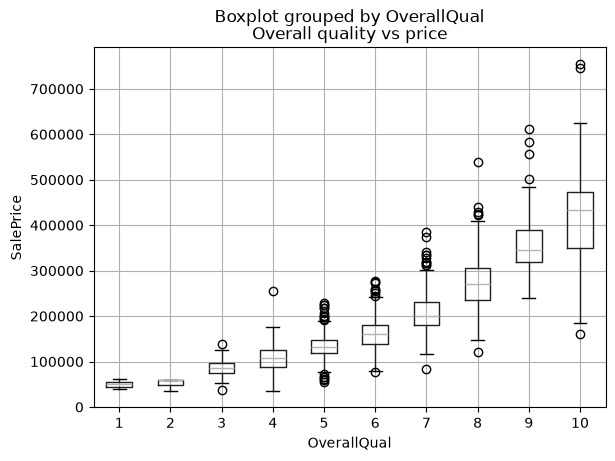

In [59]:
#We proceed in the same way, but with the OverallQual variable and this time with a boxplot, better suited to a discrete variable:
df.boxplot(column="SalePrice", by="OverallQual")
plt.title('Overall quality vs price')
plt.xlabel('OverallQual')
plt.ylabel('SalePrice')
plt.show()

We observe that, in general, the overall quality variable does give us a good rough idea of the price.
This can be seen from the fact that medians and boxes gradually increase as the overall quality increases. However,
it should be noted that it only serves as a guide, since, especially for the central values, there are many outliers beyond
the whiskers, and the boxes containing 50% of the data are quite wide.

Let's complement this with a strong categorical variable, such as `Neighborhood`:

Neighborhood
NoRidge    335295.317073
NridgHt    316270.623377
StoneBr    310499.000000
Timber     242247.447368
Veenker    238772.727273
Somerst    225379.837209
ClearCr    212565.428571
Crawfor    210624.725490
CollgCr    197965.773333
Blmngtn    194870.882353
Gilbert    192854.506329
NWAmes     189050.068493
SawyerW    186555.796610
Mitchel    156270.122449
NAmes      145847.080000
NPkVill    142694.444444
SWISU      142591.360000
Blueste    137500.000000
Sawyer     136793.135135
OldTown    128225.300885
Edwards    128219.700000
BrkSide    124834.051724
BrDale     104493.750000
IDOTRR     100123.783784
MeadowV     98576.470588
Name: SalePrice, dtype: float64


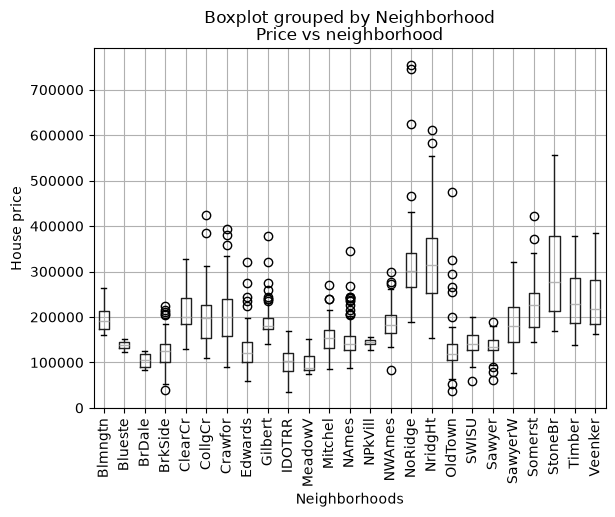

In [60]:
#We look at the average price of each neighborhood to get a first idea:
print(df.groupby("Neighborhood")["SalePrice"].mean().sort_values(ascending=False))

df.boxplot(column="SalePrice", by="Neighborhood")
plt.title('Price vs neighborhood')
plt.xlabel('Neighborhoods')
plt.ylabel('House price')
plt.xticks(rotation=90)
plt.show()

In this plot, we can see boxes and medians with large price differences, which tells us that it can potentially be
a variable that gives us a lot of information.

## 4. Modeling

In this section the predictor variables and the target variable are prepared. Then two models are trained: a linear regression and a Random Forest Regressor.

First, `SalePrice`, which will be the target variable, is separated from the rest of the variables in the dataset.

In [61]:
x = df.drop(["SalePrice", "Id"], axis=1) #We exclude the Id since it is just a classification parameter of the data set
y = df["SalePrice"]

x = pd.get_dummies(x, drop_first=True) #We have applied one-hot encoding to the categorical variables so that they can be handled.

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=0
)

As a starting point we begin with a linear regression. This helps us see whether there is some linear relationship between the predictor variables and the target. We include the resulting metrics of the model and a plot.

Linear model results:
MAE = 22661.467636693425
RMSE =  56045.540277920896
R^2 = 0.5451533697637639


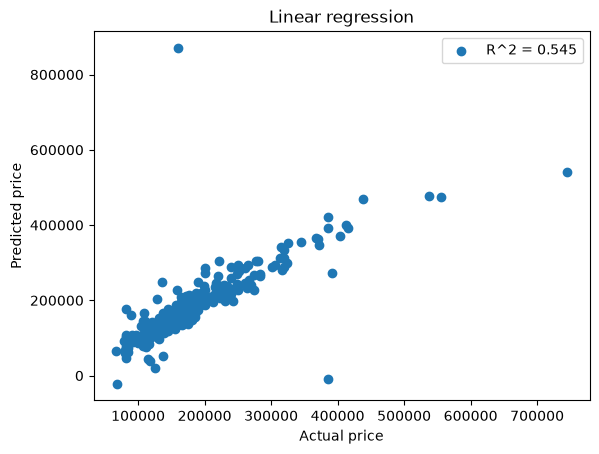

In [62]:
model = LinearRegression()
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print('Linear model results:')
print("MAE =", mae)
print('RMSE = ', rmse)
print('R^2 =', r2)

plt.figure('Linear regression')
plt.scatter(y_test, y_pred, label=f"R^2 = {r2:.3f}")
plt.title('Linear regression')
plt.xlabel('Actual price')
plt.ylabel('Predicted price')
plt.legend()
plt.show()

In the results we can observe that, due to the difference between the mae and the rmse, there are very large errors that are
lowering the quality of the model. In addition, the R2 is 0.59, which is very low.
The plot shows that for low-to-mid prices, the linear model captures the price trend reasonably well. However,
for mid-to-high prices, the dispersion increases much more, and there are outliers with huge differences between the actual and predicted price.
This leads us to remodel with Random Forest.

Random Forest results:
MAE = 17728.726506849318
RMSE =  34525.4887355982
R^2 = 0.8273913596957342


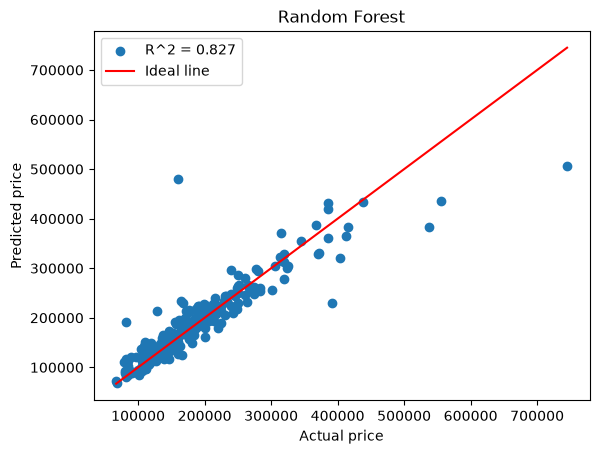

In [63]:
rf_model = RandomForestRegressor(random_state=0)
rf_model.fit(x_train, y_train)
yrf_pred = rf_model.predict(x_test)

mae_rf = mean_absolute_error(y_test, yrf_pred)
rmse_rf = np.sqrt(mean_squared_error(y_test, yrf_pred))
r2_rf = r2_score(y_test, yrf_pred)

print('Random Forest results:')
print("MAE =", mae_rf)
print('RMSE = ', rmse_rf)
print('R^2 =', r2_rf)

plt.figure('Random Forest')
plt.scatter(y_test, yrf_pred, label=f"R^2 = {r2_rf:.3f}")
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    label="Ideal line"
)
plt.title('Random Forest')
plt.xlabel('Actual price')
plt.ylabel('Predicted price')
plt.legend()
plt.show()

These are now more acceptable values. We notice that the rmse has dropped considerably. This tells us that the very large
errors made by the linear model are reasonably corrected by this new model.
Although there is also a drop in the mae, the biggest change is the increase in R^2. The R^2 obtained is already considerable for a good
model.
With this plot we finish the Random Forest conclusion by saying that it shows a fairly good fit for low-to-mid prices.
However, for higher prices, the model seems to tend to underpredict, since there are quite a few more points below
the ideal line. Although there are still striking outliers, we already saw with the drop in the rmse that the model improves considerably
on large errors, and also overall.

## 5. Feature importance

If one wanted to build a more complex model, interpret the behavior of the Random Forest or deploy it to production, as we aim to do, it could be good to study the importance of variables so we can try to reduce the number of variables.

In [64]:
importancia = rf_model.feature_importances_
importancia_df = pd.DataFrame({
    "Variable": x_train.columns,
    "Importance": importancia
})
importancia_df = importancia_df.sort_values(by="Importance", ascending=False)

print('The most important variables are:')
print(importancia_df.head(30))

The most important variables are:
              Variable  Importance
3          OverallQual    0.577451
15           GrLivArea    0.121010
11         TotalBsmtSF    0.043489
8           BsmtFinSF1    0.029284
26          GarageArea    0.022707
12            1stFlrSF    0.020938
7           MasVnrArea    0.016943
25          GarageCars    0.014797
2              LotArea    0.013145
13            2ndFlrSF    0.010457
5            YearBuilt    0.010228
6         YearRemodAdd    0.007991
24         GarageYrBlt    0.007522
10           BsmtUnfSF    0.006500
22        TotRmsAbvGrd    0.006168
34              MoSold    0.005951
1          LotFrontage    0.005717
28         OpenPorchSF    0.005100
27          WoodDeckSF    0.004806
4          OverallCond    0.004331
201     KitchenQual_Gd    0.003742
45        LotShape_Reg    0.003168
195       CentralAir_Y    0.003029
163        BsmtQual_Gd    0.002737
18            FullBath    0.002414
0           MSSubClass    0.002336
20        BedroomAbvG

## 6. Conclusions

In this project a complete machine learning process has been developed to predict house prices.

First, data cleaning was performed, handling null values and creating new binary variables to represent features. Then an exploratory data analysis was carried out to study the distribution of prices and their relationship with relevant variables such as living area, overall quality and neighborhood.

In the modeling phase two approaches were compared: a linear regression and a Random Forest Regressor. The linear regression served as a baseline model, but showed important limitations, especially for houses with mid-to-high prices and with large errors.

The Random Forest model obtained better results, reducing errors and increasing R². In addition, it made it possible to analyze the importance of the variables, which helps interpret which features carry the most weight in predicting the price.

As next improvements, cross-validation techniques, hyperparameter optimization, outlier treatment and more advanced models such as Gradient Boosting or XGBoost could be tried.

## 7. Preparation of the model for deployment

Since we are going to deploy the model with an API, it is not practical to the user having to fill 80 qualities of the house, so our goal now is seeing if we can reduce the number of variables and get similar results and satisfaction with the model. We are going to take the qualitative variable of Neighborhood which has a big correlation with SalePrice, and the 10 numerical variables with th highest importance, but watching closely on not taking highly related variables. For instance, if we pick GrLivArea, which we definitely will, we would not pick later 1stFlrSF since this variable is not giving much extra information.

First 10 are numerical variables selected, and last one is our only qualitative variable. The choice of this variables was made based on the importance of them for the
random forest itself, keeping in mind that the correlation between each other should not be high and that should be data that the user of the API can easily know.

In [66]:
x2 = df[["OverallQual","GrLivArea", "TotalBsmtSF", "GarageArea", "OverallCond", "LotArea", "YearBuilt", "YearRemodAdd", "FullBath", "OpenPorchSF", "Neighborhood"]]

x2 = pd.get_dummies(x2, drop_first= True) #We apply one-hot encoding to Neighborhood and drop first column, although in random forest is not needed.

x2_train, x2_test, y2_train, y2_test = train_test_split(x2,y, test_size=0.2, random_state=0) #We split the dataframe to train and then test the model


rf2_model = RandomForestRegressor(random_state=0) 

rf2_model.fit(x2_train, y2_train)
y2_pred = rf2_model.predict(x2_test)

#Now let's check metrics to see whether the model is still satisfatory:
mae2 = mean_absolute_error(y2_pred, y2_test)
rmse2 = np.sqrt(mean_squared_error(y2_pred,y2_test))
r2_rf2 = r2_score(y2_test,y2_pred)

print('Random Forest with reduced variable results:')
print("MAE =", mae2)
print('RMSE = ', rmse2)
print('R^2 =', r2_rf2)


Random Forest with reduced variable results:
MAE = 18415.43567873451
RMSE =  31998.319273619916
R^2 = 0.8517354935781244


About the results, we should discuss some points:
- We see that R^2 of the model with less variables is a bit higher. This is most likely not an improvement of the model, but a result of the random factor of the split taken to train and test the model. A more robust of proceeding is taking all possible splits of data and then taking mean of all results in order to see if there is real improvement. However, we will proceed this way and keeping in mind that fact.
- It can be noted that the difference between MAEs is ~700, which is not significant in this context
- The RMSE has been reduced ~2500. This tells us that in the new model, big errors weigh a bit less than in the other one.

This results lead of us of taking the decision of deploying this model, which is much user-friendly due to the small number of variables; and gets really similar results. 

The reduced model is implemented for deployment in src/train.py